## Лабораторная работа 3. Извлечение разметки из видео

In [2]:
!pip install opencv-python torch torchvision torchmetrics[detection] pycocotools pandas matplotlib gdown -q --disable-pip-version-check

In [3]:
import gdown, os

files = {
    'output.mp4':      '1QqWoLGIOdXi9ZF2a9ArDJnN94yz1ZUhY',
    'input.mp4':       '1RsM1CkcUuhH3_sufMAHhD2HG6ahc8zoc',
    'annotations.xml': '1vjwW-qrgbXMUQrsCl3ILdaXcSoBkvazn',
}

for fname, fid in files.items():
    if not os.path.exists(fname):
        gdown.download(f'https://drive.google.com/uc?id={fid}', fname, quiet=False)

In [4]:
from random import choice
import cv2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import torchvision
from torchvision.datasets import CocoDetection
import torchvision.transforms as T
import json
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader
from pathlib import Path
import os
from IPython.display import display

### Декодирование видео в кадры

Для удобства считаем информацию о видео, количество кадров, fps и разрешение

In [5]:
def video_info(path: str) -> dict:
    cap = cv2.VideoCapture(path)
    info = {
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": int(cap.get(cv2.CAP_PROP_FPS)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()
    return info


input_info = video_info('input.mp4')
output_info = video_info('output.mp4')
print("input.mp4:", input_info)
print("output.mp4:", output_info)

n_frames, fps, width, height = input_info.values()

input.mp4: {'frame_count': 301, 'fps': 30, 'width': 1920, 'height': 1080}
output.mp4: {'frame_count': 301, 'fps': 30, 'width': 1920, 'height': 1080}


Теперь декодируем видео в кадры и сохраним их в отдельные папочки

In [6]:
def decode_video(video_path: str, out_dir: str) -> list:
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    paths = []
    for i in range(n_frames):
        ok, frame = cap.read()
        path = os.path.join(out_dir, f"frame_{i:03d}.jpg")
        if ok:
            cv2.imwrite(path, frame)
        paths.append(path)
    cap.release()
    return paths


input_frame_paths = decode_video('input.mp4', './frames/input')
output_frame_paths = decode_video('output.mp4', './frames/output')

print("Извлечено кадров из input:", len(input_frame_paths))
print("Извлечено кадров из output:", len(output_frame_paths))

Извлечено кадров из input: 301
Извлечено кадров из output: 301


### Парсинг оригинальной разметки

Методом небольшого поиска выяснил, что оригинальная разметка сохранена в формате CVAT XML 1.1. Напишем парсер для этого формата.

In [7]:
def parse(xml_path: str):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    labels = []
    for label_node in root.findall(".//meta/task/labels/label"):
        labels.append(label_node.findtext("name"))

    frame_boxes = {i: [] for i in range(n_frames)}
    skipped = 0
    for track in root.findall("track"):
        track_id = track.attrib["id"]
        label = track.attrib["label"]

        for box in track.findall("box"):
            frame_id = int(box.attrib["frame"])
            if box.attrib["outside"] == "1":
                continue
            if frame_id >= n_frames:
                skipped += 1
                continue
            x1 = float(box.attrib["xtl"])
            y1 = float(box.attrib["ytl"])
            x2 = float(box.attrib["xbr"])
            y2 = float(box.attrib["ybr"])
            frame_boxes[frame_id].append({
                "bbox_xyxy": [x1, y1, x2, y2],
                "label": label,
                "track_id": track_id,
            })

    ano_info = {
        "labels": labels,
        "boxes": sum(len(v) for v in frame_boxes.values()),
        "skipped": skipped,
        "annotated_frames": len(frame_boxes),
    }
    return frame_boxes, ano_info


frames, ano_info = parse('annotations.xml')
print(ano_info)

{'labels': ['car', 'minivan'], 'boxes': 3647, 'skipped': 6012, 'annotated_frames': 301}


Теперь обозначим функцию для отрисовки разметки и сравним распаршенную разметку с размеченным видео

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

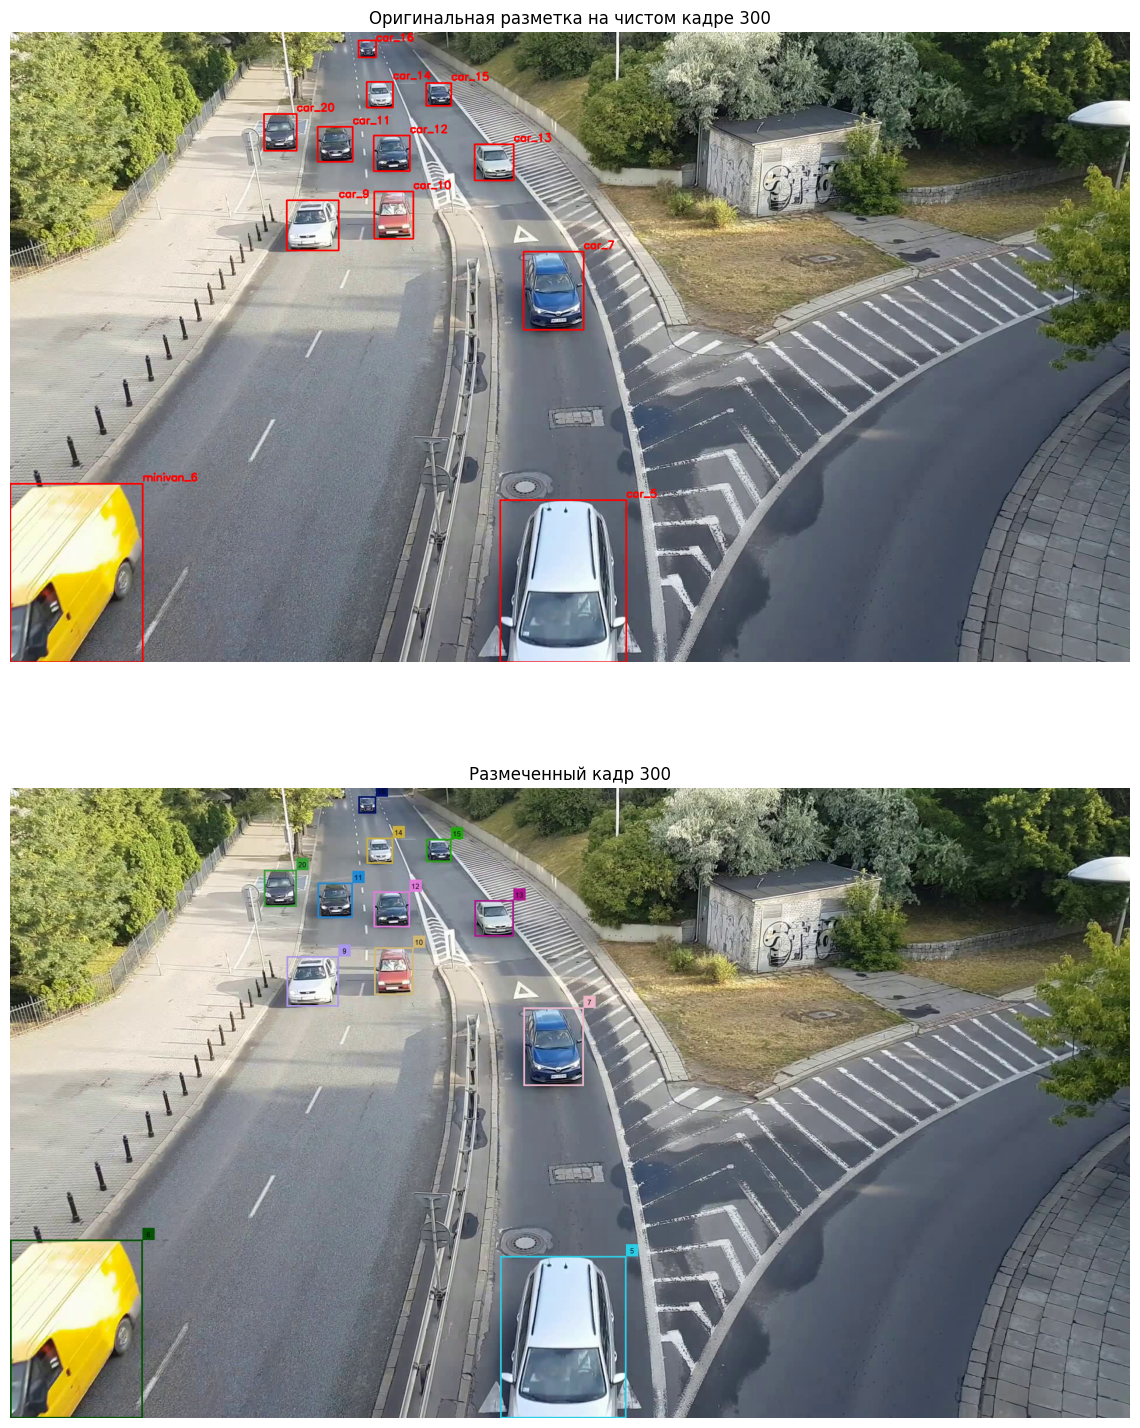

In [8]:
def read_frame(video_path: str, frame_idx: int) -> np.ndarray:
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()
    return frame


def draw_boxes(frame: np.ndarray, boxes: list, color=(0, 0, 255)) -> np.ndarray:
    image = frame.copy()
    for i, item in enumerate(boxes):
        box = item.get("bbox_xyxy", item.get("bbox"))
        track_id = int(item["track_id"]) + 1
        label = item["label"]
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, f"{label}_{track_id}", (x2, max(15, y1 - 5)), cv2.FONT_ITALIC, 0.6, color, 2)
    return image


def draw_boxes_without_tracking(frame: np.ndarray, boxes: list, color=(0, 0, 255)) -> np.ndarray:
    image = frame.copy()
    for i, item in enumerate(boxes):
        if isinstance(item, dict):
            box = item.get("bbox_xyxy", item.get("bbox"))
        else:
            box = item
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, f"{i}", (x2, max(15, y1 - 5)), cv2.FONT_ITALIC, 0.6, color, 2)
    return image


fig, ax = plt.subplots(2, 1, figsize=(16, 18))
sample_idx = 300
sample_input = read_frame('input.mp4', sample_idx)
sample_output = read_frame('output.mp4', sample_idx)
sample = frames[sample_idx]
vis = draw_boxes(sample_input, sample)

ax[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax[1].imshow(cv2.cvtColor(sample_output, cv2.COLOR_BGR2RGB))

ax[0].set_title(f"Оригинальная разметка на чистом кадре {sample_idx}")
ax[1].set_title(f"Размеченный кадр {sample_idx}")
ax[0].axis("off")
ax[1].axis("off")

### Извлечение разметки

Для извлечения разметки будем использовать 3 метода: извлечение с помощью сравнения с исходным видео по разнице (contours + threshold, canny), и метод выделения контуров по HSV. Попробуем несколько порогов и сравним результаты.

In [ ]:
def remove_nested_boxes(boxes: list) -> list:
    boxes = sorted(boxes, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]), reverse=True)
    keep = []
    for box in boxes:
        area = max(0, box[2] - box[0]) * max(0, box[3] - box[1])
        if area < 80:
            continue
        inside = False
        for kept in keep:
            ix1, iy1 = max(box[0], kept[0]), max(box[1], kept[1])
            ix2, iy2 = min(box[2], kept[2]), min(box[3], kept[3])
            inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
            if inter / (area + 1e-9) > 0.8:
                inside = True
                break
        if not inside:
            keep.append(box)
    return keep


def contour_boxes_from_mask(mask: np.ndarray) -> list:
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h
        if area < 100 or area > 100000:
            continue
        boxes.append([float(x), float(y), float(x + w), float(y + h)])
    return remove_nested_boxes(boxes)


def extract_diff_contours(input_frame: np.ndarray, output_frame: np.ndarray, threshold: int = 20) -> list:
    diff = cv2.absdiff(input_frame, output_frame)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return contour_boxes_from_mask(mask)


def extract_diff_canny(input_frame: np.ndarray, output_frame: np.ndarray, threshold: int = 20) -> list:
    diff = cv2.absdiff(input_frame, output_frame)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    edges = cv2.Canny(mask, 50, 150)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)
    return contour_boxes_from_mask(edges)


def extract_hsv_contours(input_frame: np.ndarray, output_frame: np.ndarray) -> list:
    hsv = cv2.cvtColor(output_frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([0, 50, 50]), np.array([179, 255, 255]))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return contour_boxes_from_mask(mask)


EXTRACTION_METHODS = {
    "diff_contours_th10": lambda inp, out: extract_diff_contours(inp, out, threshold=10),
    "diff_contours_th15": lambda inp, out: extract_diff_contours(inp, out, threshold=15),
    "diff_canny_th10": lambda inp, out: extract_diff_canny(inp, out, threshold=10),
    "diff_canny_th15": lambda inp, out: extract_diff_canny(inp, out, threshold=15),
    "hsv_contours": extract_hsv_contours,
}

sample_idx = 300
input_frame = read_frame('input.mp4', sample_idx)
output_frame = read_frame('output.mp4', sample_idx)
fig, ax = plt.subplots(6, 1, figsize=(16, 54))

for i, (method_name, method_fn) in enumerate(EXTRACTION_METHODS.items()):
    bboxes = method_fn(input_frame, output_frame)
    vis = draw_boxes_without_tracking(input_frame, bboxes)
    ax[i].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax[i].set_title(method_name)
    ax[i].axis("off")

ax[5].imshow(cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB))
ax[5].set_title(f"Оригинальная разметка")
ax[5].axis("off")

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

Как видим, методы, которые работают на сравнении с исходной картинкой, неплохо справляются с задачей, в то время как метод HSV-контуров даёт много лишних детекций. Оценим все методы количественно.

### Оценка качества извлеченной разметки

Обозначим функцию подсчета iou по двум bbox. Потом обозначим функцию, которая сравнивает предсказанные bbox'ы с реальными и считает метрики: tp, fp, fn, precision, recall, f1, mean_iou.

In [ ]:
def iou(a, b) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    if union == 0:
        return 0.0
    return inter / union


def match_boxes(preds, boxes) -> dict:
    used = set()
    ious = []
    tp = 0
    fp = 0

    for pred in preds:
        best_iou = 0.0
        best_j = None
        for j, gt in enumerate(boxes):
            if j in used:
                continue
            cur = iou(pred, gt)
            if cur > best_iou:
                best_iou = cur
                best_j = j

        ious.append(best_iou)
        if best_iou >= 0.5 and best_j is not None:
            tp += 1
            used.add(best_j)
        else:
            fp += 1

    fn = len(boxes) - len(used)
    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "ious": ious,
    }


def evaluate(preds, needed) -> dict:
    tp, fn, fp = 0, 0, 0
    all_ious = []

    for frame_idx in range(n_frames):
        pred_boxes = preds[frame_idx]
        boxes = [item["bbox_xyxy"] for item in needed[frame_idx]]
        matched = match_boxes(pred_boxes, boxes)

        tp += matched["tp"]
        fp += matched["fp"]
        fn += matched["fn"]
        all_ious.extend(matched["ious"])

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    return {
        "mean_iou": float(np.mean(all_ious)),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
def run_extraction_methods(methods: dict):
    predictions = {name: [] for name in methods}

    for i in range(n_frames):
        input_frame = read_frame('input.mp4', i)
        output_frame = read_frame('output.mp4', i)

        for name, func in methods.items():
            predictions[name].append(func(input_frame, output_frame))

    rows = []
    for name, preds in predictions.items():
        metrics = evaluate(preds, frames)
        row = {k: v for k, v in metrics.items() if k != "per_frame"}
        row["method"] = name
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("f1", ascending=False)
    return df, predictions


df, predictions = run_extraction_methods(EXTRACTION_METHODS)
display(df)

best_method = df.iloc[0]["method"]
best_predictions = predictions[best_method]
best_metrics = evaluate(best_predictions, frames)

print("Лучший метод:", best_method)

Теперь выведем лучшую разметку вместе с эталонной. Зелёная — эталон, красная — наша извлечённая разметка

In [ ]:
def show_double(idx, boxes, pred_boxes):
    frame = read_frame('input.mp4', idx)

    vis = draw_boxes_without_tracking(frame, boxes, color=(0, 255, 0))
    vis = draw_boxes_without_tracking(vis, pred_boxes, color=(0, 0, 255))

    plt.figure(figsize=(16, 9))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Кадр {idx}")
    plt.axis("off")
    plt.show()


for idx in [30, 60, 120, 240]:
    show_double(idx, frames[idx], best_predictions[idx])

Также отрисуем извлечённую разметку в видео.

In [ ]:
def draw_extracted_video(frames_preds, output_path: str):
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    for i in range(n_frames):
        frame = read_frame('input.mp4', i)

        for j, box in enumerate(frames_preds[i]):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 80, 255), 2)
            cv2.putText(frame, f"vehicle {j}", (x2, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 80, 255), 1,
                        cv2.LINE_AA)
        writer.write(frame)
    writer.release()


draw_extracted_video(best_predictions, './output_result.mp4')

### Сохранение разметки в COCO-формате

Для сохранения разметки в COCO формате напишем простенькую функцию для формирования словаря в нужном формате.

In [ ]:
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]


def build_coco(frames_preds) -> dict:
    coco = {
        "info": {},
        "licenses": [],
        "categories": [
            {"id": 1, "name": "vehicle", "supercategory": "vehicle"},
        ],
        "images": [],
        "annotations": [],
    }

    ann_id = 1
    for i in range(n_frames):
        file_name = f"frame_{i:03d}.jpg"
        coco["images"].append({
            "id": i + 1,
            "file_name": file_name,
            "width": width,
            "height": height,
            "frame_id": i,
        })

        for box in frames_preds[i]:
            x, y, w, h = xyxy_to_xywh(box)
            coco["annotations"].append({
                "id": ann_id,
                "image_id": i + 1,
                "category_id": 1,
                "bbox": [x, y, w, h],
                "area": float(w * h),
                "iscrowd": 0,
                "segmentation": [],
            })
            ann_id += 1

    return coco


extracted_coco = build_coco(best_predictions)
coco_file = "./annotations/coco.json"
Path("./annotations/").mkdir(parents=True, exist_ok=True)
with open(coco_file, "w", encoding="utf-8") as f:
    json.dump(extracted_coco, f, ensure_ascii=False, indent=2)

print("COCO разметка сохранена:", coco_file)
print("images:", len(extracted_coco["images"]))
print("annotations:", len(extracted_coco["annotations"]))

### Обучение модели

Для обучения детектора будем использовать извлечённую COCO-разметку. Разбиение произведём хронологически: первые 70% кадров — train, следующие 15% — val, последние 15% — test.

In [ ]:
def split_coco(coco, train_ratio, val_ratio):
    total_images = len(coco["images"])
    split_train = int(total_images * train_ratio)
    split_val = int(total_images * (train_ratio + val_ratio))

    train_ids = {img["id"] for img in coco["images"] if img["frame_id"] < split_train}
    val_ids = {img["id"] for img in coco["images"] if split_train <= img["frame_id"] < split_val}
    test_ids = {img["id"] for img in coco["images"] if img["frame_id"] >= split_val}

    def subset(image_ids):
        return {
            "info": coco.get("info", {}),
            "licenses": coco.get("licenses", []),
            "categories": coco["categories"],
            "images": [img for img in coco["images"] if img["id"] in image_ids],
            "annotations": [ann for ann in coco["annotations"] if ann["image_id"] in image_ids],
        }

    return subset(train_ids), subset(val_ids), subset(test_ids)


train_coco, val_coco, test_coco = split_coco(extracted_coco, train_ratio=0.70, val_ratio=0.15)

splits = [
    ("./annotations/train.coco.json", train_coco),
    ("./annotations/val.coco.json", val_coco),
    ("./annotations/test.coco.json", test_coco)
]

for path, data in splits:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"{path} {len(data['images'])} {len(data['annotations'])}")

Так как модели из torchvision принимают разметку в виде xyxy, то использовать готовый CocoDetection мы не сможем, поэтому создадим свой класс на его основе.

In [ ]:
class CocoDataset(CocoDetection):
    def __init__(self, root, annFile):
        super().__init__(root=root, annFile=annFile)
        self.id_to_frame = {img["id"]: img.get("frame_id", img["id"]) for img in self.coco.dataset["images"]}
        self.image_ids = list(self.coco.imgs.keys())
        self.transform = T.ToTensor()

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img, anns = super().__getitem__(idx)
        img = self.transform(img)

        boxes = []
        labels = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        if len(boxes) == 0:
            boxes = torch.empty((0, 4), dtype=torch.float32)

        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(img_id)
        }

        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))

Теперь для каждой части создадим свой класс и загрузчик, поигравшись с batch_size я поставил его 4, потому что большие значения давали нестабильный loss.

In [ ]:
img_dir = "frames/input/"
full_dataset = CocoDataset(root=img_dir, annFile="./annotations/coco.json")
train_dataset = CocoDataset(root=img_dir, annFile="./annotations/train.coco.json")
val_dataset = CocoDataset(root=img_dir, annFile="./annotations/val.coco.json")
test_dataset = CocoDataset(root=img_dir, annFile="./annotations/test.coco.json")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

Обозначим функции для инициализации модели, одного шага модели, оценки модели и тренировки. Также начнём обучать модель с предобученными весами.

In [ ]:
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_map(model, loader, device):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)

    for images, targets in loader:
        images = [img.to(device) for img in images]
        preds = model(images)

        preds = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets = [{k: v.cpu() for k, v in t.items()} for t in targets]
        metric.update(preds, targets)

    return metric.compute()

In [ ]:
def fit(model, train_loader, val_loader, device, epochs=10, patience=3, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "maps": []}
    best_map = -1
    bad_epochs = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_result = evaluate_map(model, val_loader, device)
        val_map = val_result["map"].item()

        history["train_loss"].append(train_loss)
        history["maps"].append(val_map)

        print(f"Epoch {epoch + 1}/{epochs} | loss={train_loss:.4f} | map={val_map:.4f}")

        if val_map > best_map:
            best_map = val_map
            bad_epochs = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Модель перестала улучшаться на валидации")
                break

    return history

In [ ]:
num_classes = len(train_coco["categories"]) + 1
device = 'cpu'
model = get_model(num_classes).to(device)
history = fit(model, train_loader, val_loader, device, epochs=10, patience=3)
model.load_state_dict(torch.load("best_model.pth", map_location=device, weights_only=True))

Выведем метрики по тестовой выборке

In [ ]:
test_result = evaluate_map(model, test_loader, device)
print(f"Test mAP (IoU 0.5-0.95): {test_result['map'].item():.4f}")
print(f"Test mAP@0.5:            {test_result['map_50'].item():.4f}")
print(f"Test mAP@0.75:           {test_result['map_75'].item():.4f}")
print(f"Test mAR@100:            {test_result['mar_100'].item():.4f}")

### Анализ метрик

In [ ]:
per_class_map = test_result['map_per_class']
per_class_mar = test_result['mar_100_per_class']
print("Метрики по классу:")
for i, (ap, ar) in enumerate(zip(per_class_map, per_class_mar)):
    print(f"  vehicle (class {i+1}): mAP@0.5:0.95 = {ap.item():.4f},  mAR@100 = {ar.item():.4f}")

label_counts = {}
for frame_anns in frames.values():
    for ann in frame_anns:
        label_counts[ann['label']] = label_counts.get(ann['label'], 0) + 1
total = sum(label_counts.values())
print(f"\nРаспределение классов в оригинальной XML разметке:")
for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"  {label}: {count} объектов ({count/total*100:.1f}%)")

print(f"\nВ COCO оба класса объединены в vehicle — метод извлечения их не различает.")

Нарисуем графики функции потери и map-а при обучении

In [ ]:
train_losses, val_maps = history["train_loss"], history["maps"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses, marker='o')
ax[0].set_title("Функция потерь при обучении")
ax[0].set_xlabel("Эпохи")
ax[0].set_ylabel("Loss")
ax[0].grid()

ax[1].plot(val_maps, marker='o', color='orange', label='Validation mAP@0.5:0.95')
ax[1].set_title("mAP при обучении")
ax[1].set_xlabel("Эпохи")
ax[1].set_ylabel("mAP")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

Отобразим рандомно 10 картинок с оригинальной и с определённой разметкой из тестовой выборки

In [ ]:
for i in range(10):
    img, target = choice(test_dataset)
    pred = model([img.to(device)])[0]

    img_id = target["image_id"].item()
    frame_idx = test_dataset.id_to_frame[img_id]

    pred_boxes_filtered = []
    boxes_array = pred["boxes"].detach().numpy()
    scores_array = pred["scores"].detach().numpy()

    for box, score in zip(boxes_array, scores_array):
        if score > 0.6:
            pred_boxes_filtered.append(box.tolist())

    show_double(frame_idx, frames[frame_idx], pred_boxes_filtered)

Теперь найдём кадр с лучшей и худшей детекцией из тестовой выборки и покажем их рядом.

In [ ]:
best_score, worst_score = -1.0, float('inf')
best_idx, worst_idx = -1, -1
best_pred, worst_pred = [], []

model.eval()
with torch.no_grad():
    for i in range(len(test_dataset)):
        img, target = test_dataset[i]
        img_id = target["image_id"].item()
        frame_idx = test_dataset.id_to_frame[img_id]

        pred = model([img.to(device)])[0]
        filtered = [b.tolist() for b, s in zip(pred["boxes"].cpu().numpy(), pred["scores"].cpu().numpy()) if s >= 0.6]
        gt = [item["bbox_xyxy"] for item in frames[frame_idx]]

        if len(gt) == 0:
            continue

        matched = match_boxes(filtered, gt)
        tp, fn = matched["tp"], matched["fn"]
        recall = tp / (tp + fn + 1e-9)
        mean_iou = float(np.mean(matched["ious"])) if matched["ious"] else 0.0
        quality = recall * mean_iou

        if quality > best_score:
            best_score, best_idx, best_pred = quality, frame_idx, filtered
        if quality < worst_score:
            worst_score, worst_idx, worst_pred = quality, frame_idx, filtered

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

for axis, idx, pred_b, label in [
    (ax[0], best_idx, best_pred, f"Хорошая детекция — кадр {best_idx}"),
    (ax[1], worst_idx, worst_pred, f"Плохая детекция — кадр {worst_idx}"),
]:
    vis = draw_boxes_without_tracking(read_frame('input.mp4', idx), frames[idx], color=(0, 255, 0))
    vis = draw_boxes_without_tracking(vis, pred_b, color=(0, 0, 255))
    axis.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axis.set_title(f"{label}\n(зелёный — GT, синий — предсказание)")
    axis.axis("off")

plt.tight_layout()
plt.show()

Также отрисуем полное видео с предсказаниями модели

In [ ]:
frames_preds = []
model.eval()

with torch.no_grad():
    for idx in range(len(full_dataset)):
        img, target = full_dataset[idx]
        pred = model([img.to(device)])[0]

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()

        filtered_boxes = []
        for box, score in zip(boxes, scores):
            if score >= 0.6:
                filtered_boxes.append(box.tolist())

        frames_preds.append(filtered_boxes)

draw_extracted_video(frames_preds, "predictions.mp4")

### Вывод

Сделал несколько методов для извлечения разметки из видео. Лучше всего сработал `diff_contours_th15` — разница кадров + пороговая фильтрация + контуры, F1 = 0.545 при mean IoU ~0.51. HSV-метод не зашёл — выделял всё подряд, ~16 тысяч ложных боксов на видео.

Recall вышел 0.49, то есть примерно половина машин не нашлась — в основном те, что на дальнем плане или перекрыты другими. Это ограничивает качество модели, потому что учим её на неполных данных.

Извлечённую разметку сохранил в COCO и обучил на ней `fasterrcnn_mobilenet_v3_large_fpn`. Обучал 10 эпох на CPU (~13 минут), лучший результат на 9 эпохе — val mAP 0.702. На тесте mAP@0.5 = 0.767, mAP@0.5:0.95 = 0.538. Модель нормально находит машины, но теряет мелкие и перекрытые объекты.

Отдельно car/minivan не оцениваю — при извлечении bbox'ов из разницы кадров тип транспортного средства не различается, поэтому все объекты в датасете под одним классом vehicle.